##### Import Libraries

In [1]:
# ShoW each Cell's Execution Time
# %pip install ipython-autotime  datasets boto3 python-dotenv bitsandbytes
# %pip install --upgrade transformers

# %pip install -U ipython-autotime bitsandbytes
%load_ext autotime

time: 0 ns (started: 2024-09-04 12:37:41 +03:00)


In [2]:
import torch
if torch.cuda.is_available():
    DEVICE = torch.device('cuda:0')
    print(f" DEVICE: {DEVICE}. GPU: {torch.cuda.get_device_name(0)} is available.")
else:
    DEVICE = 'cpu'
    print(f" DEVICE: {DEVICE}. No GPU available. Training will run on CPU.")

 DEVICE: cuda:0. GPU: NVIDIA GeForce RTX 4050 Laptop GPU is available.
time: 2.2 s (started: 2024-09-04 12:37:41 +03:00)


In [3]:
import numpy as np
import torch
import torch.nn as nn
from torch.optim import AdamW
import torch.nn.functional as F

from transformers import  AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, get_linear_schedule_with_warmup 
from torch.utils.data import DataLoader, Dataset, RandomSampler
from datasets import load_dataset
from torch.utils.data import Subset, Dataset
from torch.nn.utils.rnn import pad_sequence
# from torch.cuda.amp import GradScaler, autocast
from torch.amp import GradScaler, autocast

# import random
import matplotlib.pyplot as plt
from tqdm import tqdm
import time
import re
import os
from functools import partial
import boto3

import warnings
import logging
import sys
# import json
from dotenv import load_dotenv

## Local Vscode
load_dotenv()
HF_TOKEN = os.getenv('TF_TOKEN')

## Colab
# from google.colab import userdata
# HF_TOKEN= userdata.get('HF_TOKEN')

## kaggle
# from kaggle_secrets import UserSecretsClient
# user_secrets = UserSecretsClient()
# HF_TOKEN = user_secrets.get_secret("HF_TOKEN")

time: 1.5 s (started: 2024-09-04 12:37:43 +03:00)


In [4]:
warnings.filterwarnings("ignore", category=FutureWarning, module="huggingface_hub.file_download")
logging.getLogger("transformers").setLevel(logging.ERROR)

time: 0 ns (started: 2024-09-04 12:37:44 +03:00)


In [5]:
#for local vscode
sys.path.append('./src') #link to GTL libraries 
import src.guided_transfer_learning as gtl 

time: 15 ms (started: 2024-09-04 12:37:44 +03:00)


##### Functions:

In [6]:
plt.style.use('dark_background')

time: 0 ns (started: 2024-09-04 12:37:44 +03:00)


time: 0 ns (started: 2024-09-04 12:37:44 +03:00)


In [8]:
def plot_results(results, title="Train and Validation Loss"):
    train_loss = results['train_results'][0]
    val_loss = results['validation_results'][0]
    fig, axs = plt.subplots(figsize=(8, 3))
    # Plot the training and validation loss
    axs.plot(range(1,len(train_loss)+1),train_loss, label='Training Loss')
    axs.plot(val_loss, label='Validation Loss')
    axs.set_xlabel('Epoch')
    axs.set_ylabel('Loss')
    axs.set_title(title)
    axs.legend()
    plt.show()

time: 0 ns (started: 2024-09-04 12:37:44 +03:00)


##### Simple Llama from Scratch

In [9]:
class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, ff_hidden_dim):
        super(TransformerBlock, self).__init__()
        self.attention = nn.MultiheadAttention(embed_dim, num_heads)
        self.feed_forward = nn.Sequential(
            nn.Linear(embed_dim, ff_hidden_dim),
            nn.ReLU(),
            nn.Linear(ff_hidden_dim, embed_dim)
        )
        self.layer_norm1 = nn.LayerNorm(embed_dim)
        self.layer_norm2 = nn.LayerNorm(embed_dim)

    def forward(self, x):
        # Attention
        attn_output, _ = self.attention(x, x, x)
        x = self.layer_norm1(x + attn_output)
        # Feed-forward
        ff_output = self.feed_forward(x)
        x = self.layer_norm2(x + ff_output)
        return x

class SimpleLlama(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_heads, num_layers, ff_hidden_dim,pad_token_id=0):
        super(SimpleLlama, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim) 
        self.transformer_blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, ff_hidden_dim) for _ in range(num_layers)
        ]) 
        self.fc_out = nn.Linear(embed_dim, vocab_size)
        self.embed_dim = embed_dim
        self.loss_fn = nn.CrossEntropyLoss(ignore_index=pad_token_id)

    def forward(self, input_ids, attention_mask=None, labels=None):
        # Embedding
        x = self.embedding(input_ids)
        x = x.transpose(0, 1)  # Sequence-first for PyTorch Transformer        
        # Attention mask handling
        if attention_mask is not None:
            # Convert attention mask to the format expected by PyTorch Transformer
            # PyTorch's MultiheadAttention expects a mask of shape (seq_len, seq_len)
            attention_mask = attention_mask.unsqueeze(1).expand(-1, input_ids.size(1), -1)
            attention_mask = attention_mask.float().masked_fill(attention_mask == 0, float('-inf'))
        # Pass through transformer blocks
        for block in self.transformer_blocks:
            x = block(x)
        x = x.transpose(0, 1)  # Batch-first
        # Output logits
        logits = self.fc_out(x)        
        outputs = {"logits": logits}
        
        if labels is None:
            outputs['loss'] = None
        else:
            # Shift labels right by one position
            labels = labels[:, 1:].contiguous()
            logits = logits[:, :-1, :].contiguous()
            loss = self.loss_fn(logits.view(-1, logits.size(-1)), labels.view(-1))
            outputs["loss"] = loss
        return outputs
    

    def generate(self,input_ids, max_length, temperature=1.0, end_token_id=None):
        self.eval()  # Set the model to evaluation mode
        
        with torch.no_grad():
            for _ in range(max_length - len(input_ids)):
                # Forward pass
                outputs = self(input_ids)
                next_token_logits = outputs["logits"][:, -1, :]
                
                # Apply temperature
                next_token_logits = next_token_logits / temperature
                
                # Sample from the filtered distribution
                probs = F.softmax(next_token_logits, dim=-1)
                next_token = torch.multinomial(probs, num_samples=1)
                
                # Append the new token to the input sequence
                input_ids = torch.cat([input_ids, next_token], dim=-1)
                
                # Check if we've generated an end-of-sequence token
                if next_token.item() == '<|end_of_sentence|>':
                    break
                if end_token_id is not None and next_token.item() == end_token_id:
                    break
        
        return input_ids


time: 16 ms (started: 2024-09-04 12:37:44 +03:00)


In [10]:
def train_model(model, optimizer, epochs, train_loader, validation_loader, with_early_stopping=True, train_loader_sampler=None, validation_loader_sampler=None, train_verbose=True, eval_verbose=True, with_GTL=False, guidance_matrix=None, with_autocast=False,patience=3, with_lr_sceduler=False, time_to_sleep=15):
    best_val_loss = float('inf')
    epochs_without_improvement = 0
    skip = 2000 if epochs > 10000 else 300 if epochs > 1000 else 30 if epochs > 100 else 5 if epochs > 10 else 1
    model.train()
    train_loss_vals = [];  val_loss_vals = [];

    num_training_steps = len(train_loader) * epochs
    lr_scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=num_training_steps) if with_lr_sceduler  else None

    grad_scaler = GradScaler('cuda') if with_autocast else None

    print(f"# Epoch: 0  (Before start training) ")
    val_loss = evaluate_model(model, validation_loader, validation_loader_sampler, verbose=eval_verbose)
    val_loss_vals.append(val_loss)
    print("================================================================================================")
    for epoch in range(epochs):
        epoch_loss = 0.0; epoch_loss_sum = 0.0; 
        if train_verbose and ((epoch + 1) % skip == 0 or epoch == 0 or epoch == epochs - 1):
            print(f"# Epoch: {epoch+1} (Learning rate: {optimizer.param_groups[0]['lr']}) ", end='')
            
        for batch in train_loader:
            input_ids = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)

            # Use autocast for mixed precision training
            if with_autocast:
                with autocast('cuda'):
                    outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=input_ids)
                    loss = outputs['loss']
            else:
                outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=input_ids)
                loss = outputs['loss']
            
            model.zero_grad()

            if with_autocast:
                grad_scaler.scale(loss).backward() ## Scales the loss and computes gradients
                if with_GTL and guidance_matrix is None:
                    print('Guidance matrix is not provided')
                    return None
                if with_GTL and guidance_matrix is not None:
                    gtl.apply_guidance(model, guidance_matrix)

                grad_scaler.step(optimizer) ## Applies the scaled gradients to the optimizer.
                grad_scaler.update() ## Adjusts the scaling factor for the next iteration.
            else:
                loss.backward() # Calculate the gradients for the loss w.r.t the parameters 
                if with_GTL and guidance_matrix is None:
                    print('Guidance matrix is not provided')
                    return None
                if with_GTL and guidance_matrix is not None:
                    gtl.apply_guidance(model, guidance_matrix)
                optimizer.step() # Update the values of parameters  with the gradients 

            epoch_loss_sum += loss.item() 
                       
            if with_lr_sceduler:
                lr_scheduler.step()  
        
        epoch_loss = epoch_loss_sum / len(train_loader)
        train_loss_vals.append(epoch_loss)
        val_loss = evaluate_model(model, validation_loader, validation_loader_sampler, verbose=False)
        val_loss_vals.append(val_loss)

        if with_early_stopping:
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += 1
                if epochs_without_improvement == patience:
                    print(f'Early stopping after {epochs_without_improvement+1} epochs without improvement.')
                    print(f'- Training loss: {epoch_loss:.2f} || Validation loss: {val_loss:.2f} \n ')
                    break

        if train_verbose and ((epoch + 1) % skip == 0 or epoch == 0 or epoch == epochs - 1):
            print(f' Training loss: {epoch_loss:.2f} || Validation loss: {val_loss:.2f}')
        time.sleep(time_to_sleep)
    return {'train_results': [train_loss_vals], 'validation_results': [val_loss_vals],}

# Define the evaluation function
def evaluate_model(model, loader, loader_sampler=None, verbose=True, dataset_category="Validation", with_autocast=False):
    model.eval() 
    total_loss = 0; 
    if verbose:
        print(f"# Evaluating on {dataset_category} Dateset: ", end= '')
    with torch.no_grad():
        for batch in loader:
        # for batch in loader:
            input_ids = batch['input_ids'].to(device=DEVICE)
            attention_mask = batch['attention_mask'].to(device=DEVICE) # mask for attention
            
            if with_autocast:
                with autocast('cuda'):
                    outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=input_ids)
                    loss = outputs['loss']
            else:
                outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=input_ids)
                loss = outputs['loss']
            total_loss += loss.item()
    avg_loss = total_loss / len(loader)
    if verbose:
        print(f'# {dataset_category} loss: {avg_loss:.2f} ')
    return avg_loss

# time.sleep(1000)

time: 0 ns (started: 2024-09-04 12:37:44 +03:00)


In [11]:
# thepile_10k = load_dataset("NeelNanda/pile-10k") 

time: 6.42 s (started: 2024-09-04 12:37:44 +03:00)


In [12]:
class CustomDataset(torch.utils.data.Dataset):
    """
    This is a custom PyTorch dataset class that tokenizes text data on-the-fly when an item is requested from the dataset.
    This approach allows for efficient memory usage, as the text data is not tokenized until it is actually needed, and
    the tokenized sequences are not stored in memory. However, it may be slower than tokenizing all of the data upfront,
    especially if the tokenizer is slow.
    """
    def __init__(self, texts, tokenizer, max_length=None):
        self.texts = texts
        self.tokenizer = tokenizer
        self.max_length = max_length
        
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = self.texts[idx]
        tokens = self.tokenizer(
            text,
            max_length=self.max_length,
            truncation=True,
            padding=False,  # No padding here
            return_tensors="pt"
        )
        return {
            "input_ids": tokens['input_ids'].squeeze(0), 
            "attention_mask": tokens['attention_mask'].squeeze(0)
            } 


time: 0 ns (started: 2024-09-04 12:37:51 +03:00)


In [13]:
def collate_fn(batch):
    """
    This is a custom collate function for a PyTorch DataLoader that pads sequences to the same length.
    The function takes in a batch of items, where each item is a dictionary containing the input_ids and attention_mask tensors.
    It extracts the input_ids and attention_masks from the batch and stores them in separate lists.    
    """
    input_ids = [item['input_ids'] for item in batch]
    attention_masks = [item['attention_mask'] for item in batch]

    # Pad sequences to the same length
    input_ids_padded = pad_sequence(input_ids, batch_first=True, padding_value=llama3_tokenizer.pad_token_id)
    attention_masks_padded = pad_sequence(attention_masks, batch_first=True, padding_value=0)

    return {
        'input_ids': input_ids_padded,
        'attention_mask': attention_masks_padded
        }

time: 0 ns (started: 2024-09-04 12:37:51 +03:00)


In [15]:
# Load the tokenizer of LLama from Hugging face
model_name = "meta-llama/Meta-Llama-3.1-8B"
llama3_tokenizer = AutoTokenizer.from_pretrained(model_name,token=HF_TOKEN)
llama3_tokenizer.pad_token = llama3_tokenizer.eos_token

time: 438 ms (started: 2024-09-04 12:40:37 +03:00)


In [16]:
# Example usage
vocab_size = len(llama3_tokenizer)     #128256  
embed_dim = 1         #4096   # Example embedding dimension
num_heads = 1         #32     # Number of attention heads
num_layers = 1        #32     # Number of transformer layers
ff_hidden_dim = 1     #4096   # Feed-forward hidden dimension

simple_llama3_model = SimpleLlama(vocab_size, embed_dim, num_heads, num_layers, ff_hidden_dim).to(DEVICE)

time: 344 ms (started: 2024-09-04 12:40:39 +03:00)


In [20]:
llama3_scouts = gtl.create_scouts(simple_llama3_model, should_save_guidance=False, should_save_scouts=False, use_squared_differences=True)
print("Scouts created")

Scouts created
time: 16 ms (started: 2024-09-04 12:41:07 +03:00)


Start Training Scouts:

# Epoch: 0  (Before start training) 
# Evaluating on Validation Dateset: # Validation loss: 11.84 
# Epoch: 1 (Learning rate: 2e-05)  Training loss: 11.84 || Validation loss: 11.84
# Epoch: 2 (Learning rate: 2e-05)  Training loss: 11.84 || Validation loss: 11.84
{'train_results': [[11.84437370300293, 11.844332695007324]], 'validation_results': [[11.835882186889648, 11.835866928100586, 11.835850715637207]]}


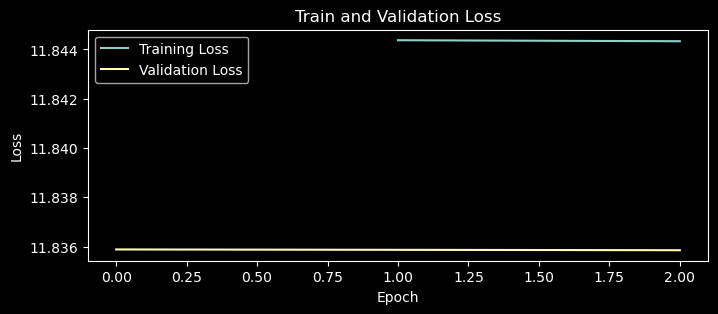

# Epoch: 0  (Before start training) 
# Evaluating on Validation Dateset: # Validation loss: 11.90 
# Epoch: 1 (Learning rate: 2e-05)  Training loss: 11.88 || Validation loss: 11.90
# Epoch: 2 (Learning rate: 2e-05)  Training loss: 11.88 || Validation loss: 11.90
{'train_results': [[11.879056930541992, 11.879015922546387]], 'validation_results': [[11.903033256530762, 11.9030179977417, 11.903003692626953]]}


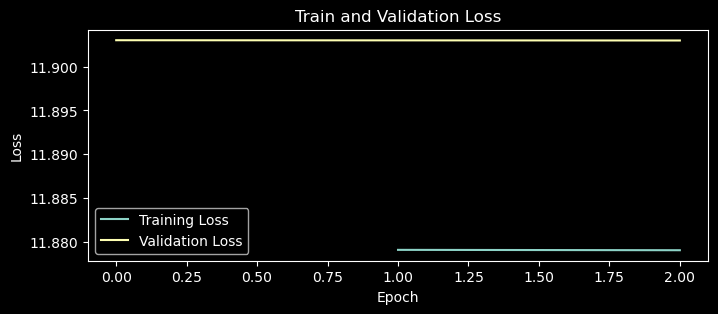

All Scouts Training End.

time: 1min 21s (started: 2024-09-04 12:41:08 +03:00)


In [21]:
# num_labels = 10 #already defined in whe crating reference BERT_Classification_model
NB_SCOUTS = 2
EPOCHS = 2
PATIENCE = 2
BATCH_SIZE = 8
LOSS_FUNCTION = nn.CrossEntropyLoss()  # Combines the softmax activation function and the negative log-likelihood loss in a single operation
LEARNING_RATE = 2e-5
MAX_LENGTH = 128
ITEMS_FROM_SUBEST_NB = 5


print("Start Training Scouts:\n")
for _ in range(NB_SCOUTS):
    # add train and validation to the dataset : 
    dataset = load_dataset("NeelNanda/pile-10k", split={'train': 'train[:80%]', 'validation': 'train[80%:]'})  

    train_dataset = dataset['train'][:ITEMS_FROM_SUBEST_NB]
    val_dataset = dataset['validation'][:ITEMS_FROM_SUBEST_NB]
    
    thepile_custom_train_subset = CustomDataset(train_dataset['text'],tokenizer=llama3_tokenizer,max_length=MAX_LENGTH )
    thepile_custom_val_subset = CustomDataset(val_dataset['text'],tokenizer=llama3_tokenizer,max_length=MAX_LENGTH )

    train_dataloader = DataLoader(thepile_custom_train_subset, batch_size=BATCH_SIZE, collate_fn=collate_fn, shuffle=True)
    val_dataloader = DataLoader(thepile_custom_val_subset, batch_size=BATCH_SIZE, collate_fn=collate_fn, shuffle=True)
    simple_llama3_scout = SimpleLlama(vocab_size, embed_dim, num_heads, num_layers, ff_hidden_dim).to(DEVICE)
    
    print('================================================================')
    losses = train_model(simple_llama3_scout,
                         optimizer=AdamW(simple_llama3_scout.parameters(),lr=LEARNING_RATE),
                         epochs=EPOCHS,
                         train_loader=train_dataloader,
                         validation_loader=val_dataloader,
                         train_verbose=True, 
                         eval_verbose=True,
                         with_early_stopping=False,
                         with_autocast=False, #cannot use autocast when the model is downloaded in bfloat16
                         with_lr_sceduler=False,                                 
                        )
    print(losses)
    plot_results(losses)

    llama3_scouts.add_scout(simple_llama3_scout) 

print(f"All Scouts Training End.\n=============================================================\n")



In [22]:
# Create the guidance matrix from the scouts:
simplellama3_raw_guidance_matrix = llama3_scouts.create_raw_guidance(DEVICE) 

time: 16 ms (started: 2024-09-04 12:43:47 +03:00)


In [23]:
gtl.save_guidance_matrix(simplellama3_raw_guidance_matrix, name='simplellama3_raw_guidance_matrix.pt')

WindowsPath('c:/Users/user/Desktop/My_Files/Anaconda  Projects/DevTechPro/Notebooks/Guided Transfer Learning-DevTech/guided_transfer_learning_library/simplellama3_raw_guidance_matrix.pt')

time: 16 ms (started: 2024-09-04 12:43:48 +03:00)


In [ ]:
bucket_name = 'gtl-bucket'
s3_file_path = 'Testing/simple_llama3_model.pt'  
local_file_path = 'simple_llama3_model.pt'

upload_to_s3(local_file_path, bucket_name, s3_file_path)

In [ ]:
bucket_name = 'gtl-bucket'
s3_file_path = 'Testing/simplellama3_raw_guidance_matrix.pt'  
local_file_path = 'simplellama3_raw_guidance_matrix.pt'

upload_to_s3(local_file_path, bucket_name, s3_file_path)

#### Load the Guidance matrix and the LLM (simple Llama in our case) from S3 bucket

In [44]:
# %pip install boto3

time: 0 ns (started: 2024-09-04 13:19:51 +03:00)


In [ ]:
os.environ['AWS_ACCESS_KEY_ID'] = 'your_access_key_id'
os.environ['AWS_SECRET_ACCESS_KEY'] = 'your_secret_access_key'
os.environ['AWS_DEFAULT_REGION'] = 'your_region'


In [ ]:
def download_from_s3(bucket_name, s3_file_path, local_file_path):
    s3 = boto3.client('s3')
    s3.download_file(bucket_name, s3_file_path, local_file_path)
    print(f'File s3://{bucket_name}/{s3_file_path} downloaded to {local_file_path}')

def upload_to_s3(local_file_path, bucket_name, s3_file_path):
    s3 = boto3.client('s3')
    s3.upload_file(local_file_path, bucket_name, s3_file_path)
    print(f'File {local_file_path} uploaded to s3://{bucket_name}/{s3_file_path}')

In [ ]:
bucket_name = 'gtl-bucket'
s3_file_path = 'Testing/simple_llama3_model.pt'  
local_file_path = 'simple_llama3_model.pt'

download_from_s3(bucket_name, s3_file_path, local_file_path)


In [ ]:
bucket_name = 'gtl-bucket'
s3_file_path = 'Testing/model.pt'  
local_file_path = 'simplellama3_raw_guidance_matrix.pt'

download_from_s3(bucket_name, s3_file_path, local_file_path)

#### Load a .jsonl file as a test data file


In [42]:
dataset = load_dataset('json', data_files='.\sample_data.jsonl')
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 10
    })
})
time: 2.88 s (started: 2024-09-04 12:59:17 +03:00)


In [ ]:
bucket_name = 'gtl-bucket'
s3_file_path = 'Testing/sample_data.jsonl'  
local_file_path = 'sample_data.jsonl'

download_from_s3(bucket_name, s3_file_path, local_file_path)

- Few-Shot Learn with using the guidance matrix and the loaded data as jsonl file 

# Llama-3 Reference Model loaded.
# Epoch: 0  (Before start training) 
# Evaluating on Validation Dateset: # Validation loss: 12.14 
# Epoch: 1 (Learning rate: 2e-05)  Training loss: 11.91 || Validation loss: 12.14
{'train_results': [[11.91403579711914]], 'validation_results': [[12.14026165008545, 12.140244483947754]]}


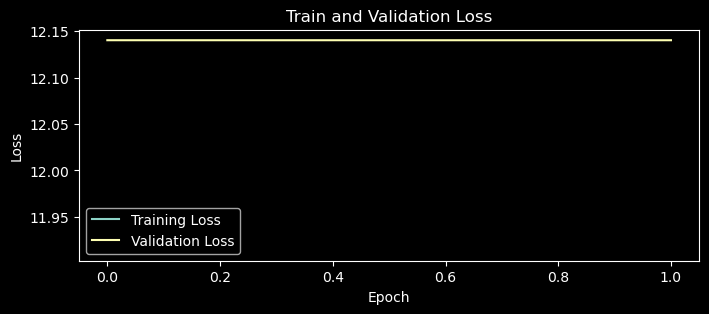

time: 17.1 s (started: 2024-09-04 12:53:01 +03:00)


In [38]:
##  Take one or more  items fron wikitext for Few-shot learn:
NUM_SAMPLES = 1
EPOCHS = 1
BATCH_SIZE = 8
LOSS_FUNCTION = nn.CrossEntropyLoss()  # Combines the softmax activation function and the negative log-likelihood loss in a single operation
LEARNING_RATE = 2e-5
MAX_LENGTH = 128
ITEMS_FROM_SUBEST_NB = 5

# dataset = load_dataset("wikitext", "wikitext-103-raw-v1", split={'train': 'train[:80%]', 'validation': 'train[80%:]'}) 
dataset = load_dataset('json', data_files='.\sample_data.jsonl',split={'train': 'train[:80%]', 'validation': 'train[80%:]'})

wikitext_train_dataset = dataset['train'][:NUM_SAMPLES]
wikitext_val_dataset = dataset['validation'][:NUM_SAMPLES]

wikitext_custom_dataset = CustomDataset(wikitext_train_dataset['text'], tokenizer=llama3_tokenizer,max_length=MAX_LENGTH )
wikitext_val_dataset = CustomDataset(wikitext_val_dataset['text'],tokenizer=llama3_tokenizer,max_length=MAX_LENGTH )

# Create DataLoaders
train_dataloader = DataLoader(wikitext_custom_dataset, batch_size=BATCH_SIZE, collate_fn=collate_fn, shuffle=True)
val_dataloader = DataLoader(wikitext_val_dataset, batch_size=BATCH_SIZE,collate_fn=collate_fn, shuffle=True)

# Load reference model:
# llama3_model.load_state_dict(torch.load(reference_model_path))

simple_llama3_model = SimpleLlama(vocab_size, embed_dim, num_heads, num_layers, ff_hidden_dim).to(DEVICE)


print(f"# Llama-3 Reference Model loaded.") 
# train model (not intersted in results: _)
print('================================================================')

simple_llama_3_losses = train_model(simple_llama3_model,
                             optimizer=AdamW(simple_llama3_model.parameters(),lr=LEARNING_RATE),
                             epochs=EPOCHS,
                             train_loader=train_dataloader,
                             validation_loader=val_dataloader,
                             train_verbose=True, 
                             eval_verbose=True,
                             with_GTL=True,
                             guidance_matrix=simplellama3_raw_guidance_matrix,
                             with_autocast=False, 
                             with_lr_sceduler=False
                             )

print(simple_llama_3_losses) 
plot_results(simple_llama_3_losses) 

- Saving the model after training with GTL (optionally)

In [39]:
torch.save(simple_llama3_model, 'few-shot-learn-trained-model.pt') #or download to user , or save in S3 bucket 

time: 16 ms (started: 2024-09-04 12:53:51 +03:00)


In [ ]:
bucket_name = 'gtl-bucket'
s3_file_path = 'Testing/few-shot-learn-trained-model.pt'  
local_file_path = 'few-shot-learn-trained-model.pt'

upload_to_s3(local_file_path, bucket_name, s3_file_path)